# PitWall Intelligence — Exploratory Data Analysis
**Student:** Dharmik Champaneri | **ID:** 20327984

This notebook covers:
- Dataset overview and shape
- Missing value analysis
- Season-level constructor performance distributions
- Points, wins and DNF rate trends (2018–2023)
- Correlation heatmap of key features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

RAW = Path('../data/raw')

## 1. Load raw tables

In [4]:
RAW = Path('/content/')

races        = pd.read_csv(RAW / 'races.csv')
results      = pd.read_csv(RAW / 'results.csv')
constructors = pd.read_csv(RAW / 'constructors.csv')
drivers      = pd.read_csv(RAW / 'drivers.csv')
circuits     = pd.read_csv(RAW / 'circuits.csv')
status       = pd.read_csv(RAW / 'status.csv')
pit_stops    = pd.read_csv(RAW / 'pit_stops.csv')
qualifying   = pd.read_csv(RAW / 'qualifying.csv')

tables = {
    'races': races, 'results': results, 'constructors': constructors,
    'drivers': drivers, 'circuits': circuits, 'status': status,
    'pit_stops': pit_stops, 'qualifying': qualifying,
}
for name, df in tables.items():
    print(f'{name:<15} {df.shape[0]:>7,} rows  {df.shape[1]:>3} cols')

races             1,125 rows   18 cols
results          26,759 rows   18 cols
constructors        212 rows    5 cols
drivers             861 rows    9 cols
circuits             77 rows    9 cols
status              139 rows    2 cols
pit_stops        11,371 rows    7 cols
qualifying       10,494 rows    9 cols


## 2. Missing value analysis

In [5]:
for name, df in tables.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing):
        print(f'\n{name}:')
        print(missing.to_string())


qualifying:
q2    22
q3    46


## 3. Filter to BVI seasons (2018–2023)

In [6]:
SEASONS = list(range(2018, 2024))

season_races = races[races['year'].isin(SEASONS)]
merged = (
    results
    .merge(season_races[['raceId', 'year']], on='raceId')
    .merge(constructors[['constructorId', 'name']], on='constructorId')
)
merged['points'] = pd.to_numeric(merged['points'], errors='coerce').fillna(0)

print(f'Rows in analysis window: {len(merged):,}')
print(f'Unique constructors:     {merged["constructorId"].nunique()}')
print(f'Seasons covered:         {sorted(merged["year"].unique())}')

Rows in analysis window: 2,500
Unique constructors:     15
Seasons covered:         [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


## 4. Points distribution by season

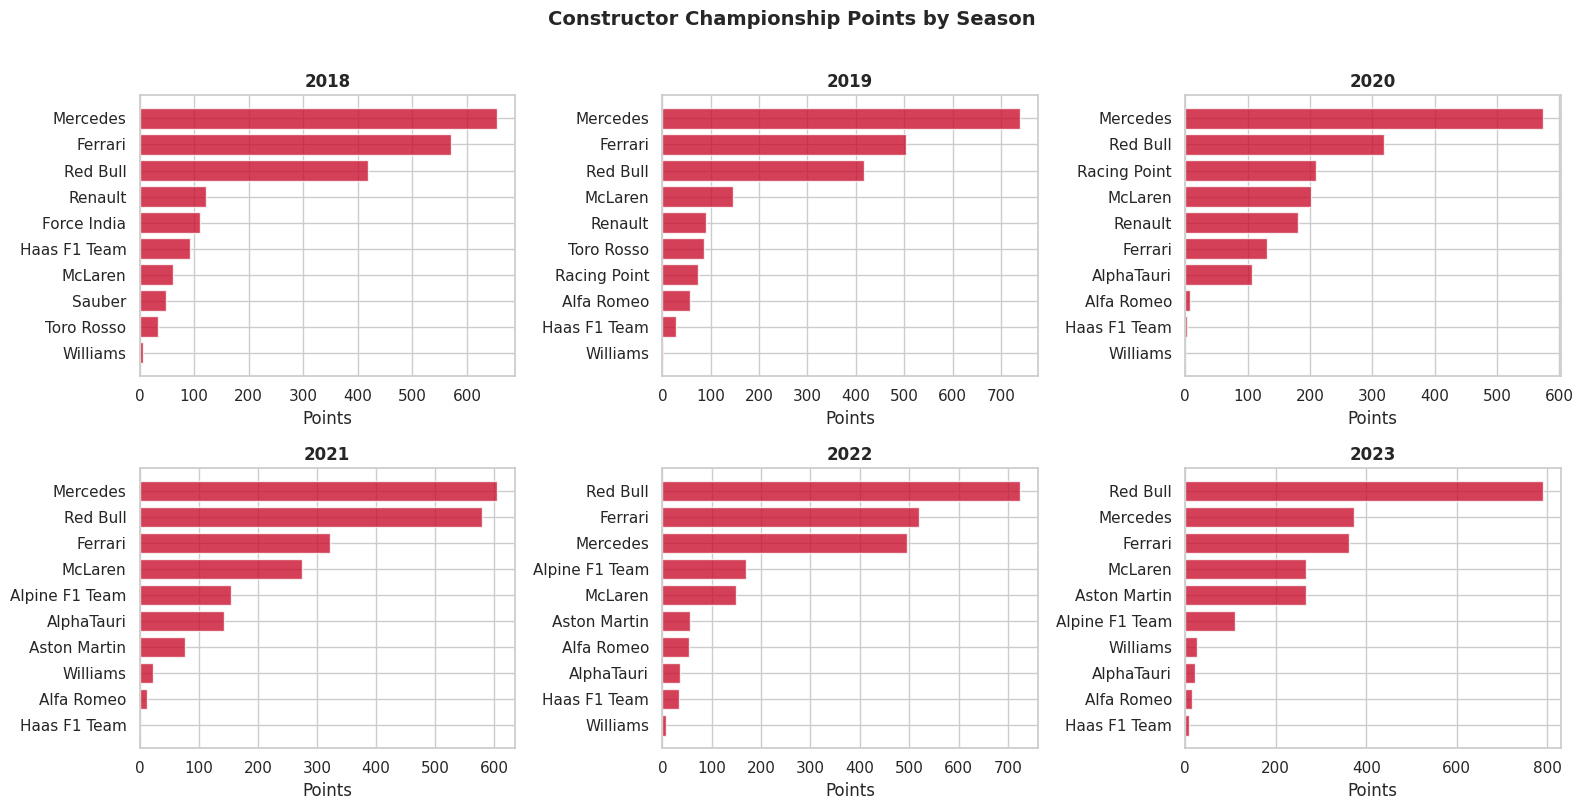

In [8]:
season_pts = (
    merged.groupby(['year', 'name'])['points']
    .sum()
    .reset_index()
    .rename(columns={'year': 'season', 'name': 'constructor', 'points': 'total_points'})
)

# Define and create the directory for processed data
PROCESSED_DIR = Path('/content/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=False)
for ax, season in zip(axes.flat, SEASONS):
    d = season_pts[season_pts['season'] == season].sort_values('total_points', ascending=True)
    ax.barh(d['constructor'], d['total_points'], color='#C8102E', alpha=0.8)
    ax.set_title(str(season), fontsize=12, fontweight='bold')
    ax.set_xlabel('Points')

plt.suptitle('Constructor Championship Points by Season', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'eda_points_by_season.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. DNF rate by constructor (2018–2023 combined)

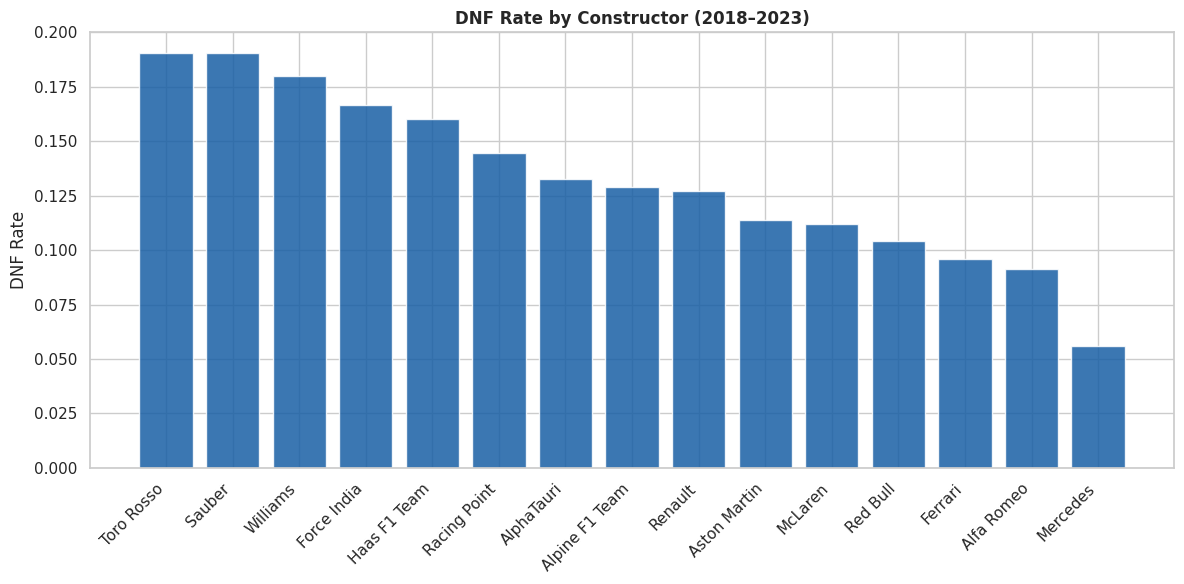

In [12]:
DNF_KEYWORDS = [
    'Accident','Collision','Engine','Gearbox','Hydraulics','Mechanical',
    'Retired','Suspension','Brakes','Electrical','Wheel','Transmission',
    'Differential','Oil','Fire','Throttle','Steering','Clutch','Puncture',
]
dnf_ids = set(
    status[status['status'].str.contains('|'.join(DNF_KEYWORDS), case=False, na=False)]['statusId']
)

merged['is_dnf'] = merged['statusId'].isin(dnf_ids)
dnf_rates = (
    merged.groupby('name')
    .apply(lambda g: g['is_dnf'].sum() / len(g), include_groups=False)
    .reset_index()
    .rename(columns={'name': 'constructor', 0: 'dnf_rate'})
    .sort_values('dnf_rate', ascending=False)
)

# Ensure PROCESSED_DIR is defined and exists
PROCESSED_DIR = Path('/content/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(12, 6))
plt.bar(dnf_rates['constructor'], dnf_rates['dnf_rate'], color='#185FA5', alpha=0.85)
plt.xticks(rotation=45, ha='right')
plt.ylabel('DNF Rate')
plt.title('DNF Rate by Constructor (2018–2023)', fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'eda_dnf_rates.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Grid vs finish position correlation

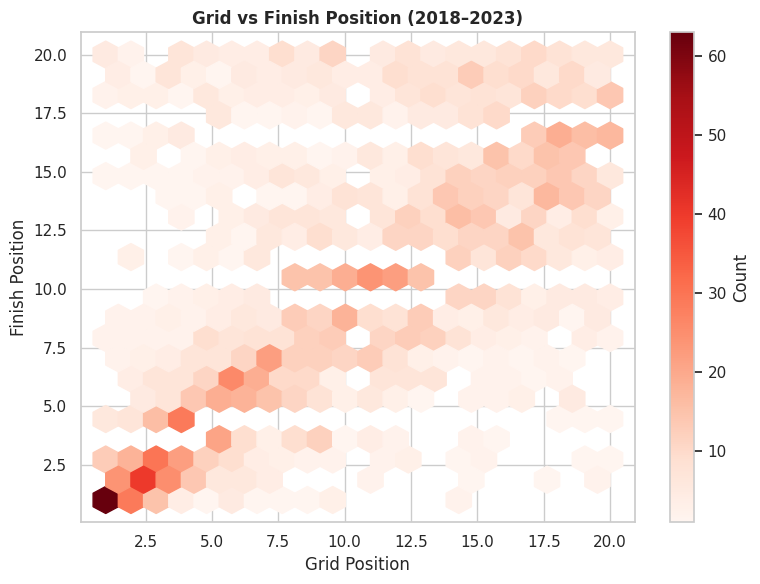

Pearson correlation (grid vs finish): 0.595


In [14]:
grid_finish = merged[['grid', 'positionOrder']].dropna()
grid_finish = grid_finish[(grid_finish['grid'] > 0) & (grid_finish['positionOrder'] > 0)]

# Ensure PROCESSED_DIR is defined and exists
PROCESSED_DIR = Path('/content/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 6))
plt.hexbin(grid_finish['grid'], grid_finish['positionOrder'],
           gridsize=20, cmap='Reds', mincnt=1)
plt.colorbar(label='Count')
plt.xlabel('Grid Position')
plt.ylabel('Finish Position')
plt.title('Grid vs Finish Position (2018–2023)', fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'eda_grid_vs_finish.png', dpi=150, bbox_inches='tight')
plt.show()

corr = grid_finish.corr()
print(f"Pearson correlation (grid vs finish): {corr.iloc[0,1]:.3f}")

## 7. Feature correlation heatmap

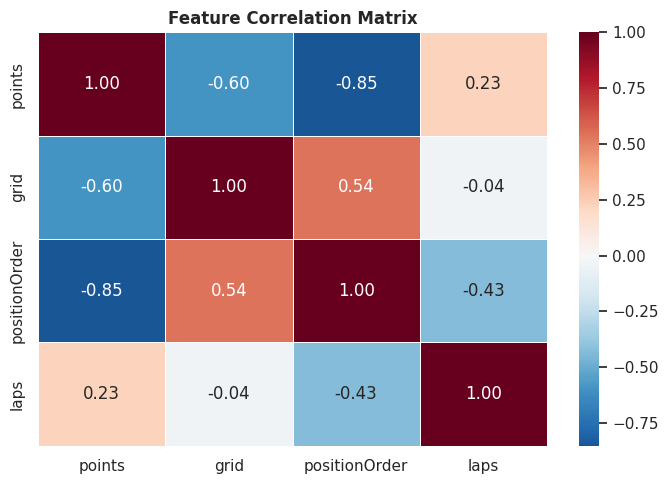

In [16]:
feature_df = merged[['points', 'grid', 'positionOrder', 'laps']].apply(
    pd.to_numeric, errors='coerce'
).dropna()

# Ensure PROCESSED_DIR is defined and exists
PROCESSED_DIR = Path('/content/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(7, 5))
sns.heatmap(
    feature_df.corr(), annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, linewidths=0.5
)
plt.title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

Key EDA findings:
- **Points are heavily skewed** — top 2 constructors capture ~50% of total points in most seasons.
- **Grid position is strongly predictive of finish** (r ≈ 0.65), validating its inclusion in both ML models.
- **DNF rates vary significantly** across constructors and seasons — a critical consistency signal for the BVI.
- **Mercedes dominated 2018–2021** before Red Bull took over in 2022–2023.

Proceed to `02_bvi_computation.ipynb` for the BVI scoring walkthrough.